# Example 6.7 Maximization Bias Example
The MDP has two non-terminal states **A** and **B**.\
Episodes always start in **A** with a choice between two actions, **left** and **right**.\
The **right** action transitions immediately to the terminal state with a reward and return of zero.\
The **left** action transitions to **B**, also with a reward of zero, from which there are many possible actions all of whice cause immediate termination with a reward drawn from a normal distribution with mean -0.1 and variance 1.0.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
states = ["A", "B", "end"]
N = 25
actions = {"A" : ["left", "right"], "B" : ["left " + str(n+1) for n in range(N)], "end" : ["None"]}
T = 100
start = "A"
goal = "end"
epsilon = 0.1
alpha = 0.5
random.seed(1234)

In [3]:
def takeAction(state, action):
    if state == "A":
        if action == "left":
            reward = 0
            nextState = "B"
        else:
            reward = 0
            nextState = "end"
    else:
        reward = random.normalvariate(-0.1)
        nextState = "end"
    return reward, nextState

In [4]:
def decideAction(Q, state, epsilon):
    sample = random.random()
    if sample < epsilon:
        # random
        return actions[state][random.choice([num for num in range(len(actions[state]))])]
    else:
        # greedy
        maxQ = -1e6
        optimalAction = None
        for action in actions[state]:
            if Q[state][action] > maxQ:
                maxQ = Q[state][action]
                optimalAction = action
        return optimalAction

## Q-learning

In [5]:
Q = {state : {action : 0 for action in actions[state]} for state in states}
results = []
Qvalues = []
for t in range(T):
    currState = start
    while currState != goal:
        currAction = decideAction(Q, currState, epsilon / (t + 1))
        reward, nextState = takeAction(currState, currAction)
        optimalAction = decideAction(Q, nextState, -1)
        if nextState == "B":
            Qvalues.append(Q[nextState][optimalAction])
        Q[currState][currAction] = Q[currState][currAction] + alpha * (reward + Q[nextState][optimalAction] - Q[currState][currAction])
        currState = nextState
    results.append(decideAction(Q, start, -1))

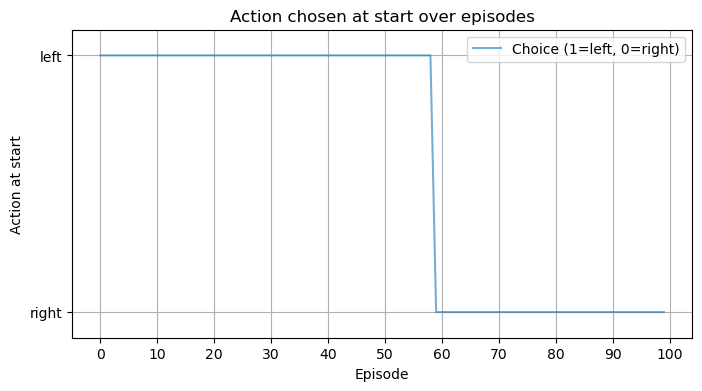

In [6]:
# convert results to numeric (1 for any 'left*', 0 for 'right')
choices = [1 if str(a).startswith('left') else 0 for a in results]

plt.figure(figsize=(8, 4))
plt.plot(choices, linestyle='-', alpha=0.6, label='Choice (1=left, 0=right)')

plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], ['right', 'left'])
plt.xticks([n for n in range(0, T + 1, int(T / 10))])
plt.xlabel('Episode')
plt.ylabel('Action at start')
plt.title('Action chosen at start over episodes')
plt.grid(True)
plt.legend()
plt.show()

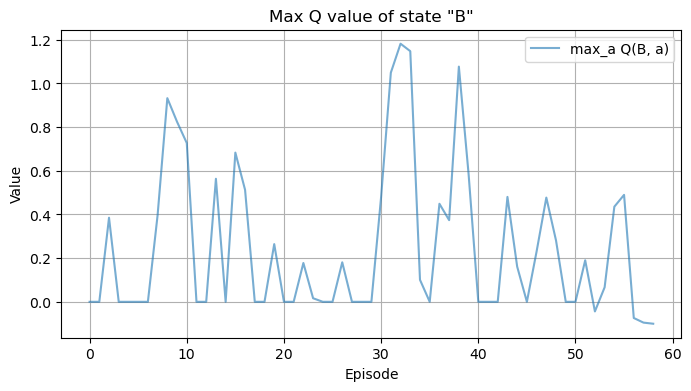

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(Qvalues, linestyle='-', alpha=0.6, label='max_a Q(B, a)')

plt.xlabel('Episode')
plt.ylabel('Value')
plt.title('Max Q value of state \"B\"')
plt.grid(True)
plt.legend()
plt.show()

## Double learning

In [8]:
def sumQ(Q1, Q2):
    Q = {state : {action : 0 for action in actions[state]} for state in states}
    for state in states:
        for action in actions[state]:
            Q[state][action] = Q1[state][action] + Q2[state][action]
    return Q

In [9]:
random.seed(1234)
Q1 = {state : {action : 0 for action in actions[state]} for state in states}
Q2 = {state : {action : 0 for action in actions[state]} for state in states}
results = []
Qvalues = []
for t in range(T):
    currState = start
    while currState != goal:
        currAction = decideAction(sumQ(Q1, Q2), currState, epsilon / (t + 1))
        reward, nextState = takeAction(currState, currAction)
        if random.random() <= 0.5:
            optimalAction = decideAction(Q1, nextState, -1)
            if nextState == "B":
                Qvalues.append(Q2[nextState][optimalAction])
            Q1[currState][currAction] = Q1[currState][currAction] + alpha * (reward + Q2[nextState][optimalAction] - Q1[currState][currAction])
        else:
            optimalAction = decideAction(Q2, nextState, -1)
            if nextState == "B":
                Qvalues.append(Q1[nextState][optimalAction])
            Q2[currState][currAction] = Q2[currState][currAction] + alpha * (reward + Q1[nextState][optimalAction] - Q2[currState][currAction])
        currState = nextState
    results.append(decideAction(sumQ(Q1, Q2), start, -1))

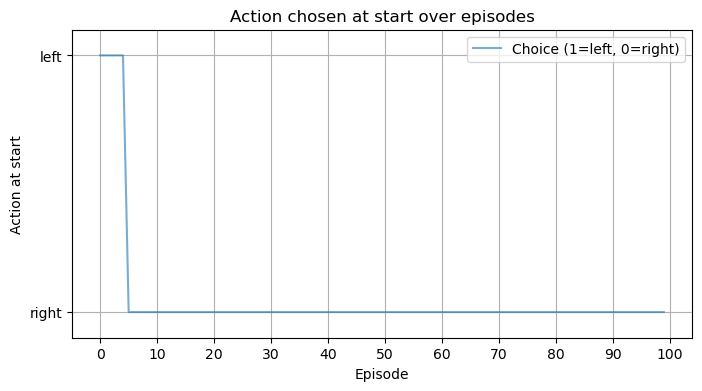

In [10]:
# convert results to numeric (1 for any 'left*', 0 for 'right')
choices = [1 if str(a).startswith('left') else 0 for a in results]

plt.figure(figsize=(8, 4))
plt.plot(choices, linestyle='-', alpha=0.6, label='Choice (1=left, 0=right)')

plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], ['right', 'left'])
plt.xticks([n for n in range(0, T + 1, int(T / 10))])
plt.xlabel('Episode')
plt.ylabel('Action at start')
plt.title('Action chosen at start over episodes')
plt.grid(True)
plt.legend()
plt.show()

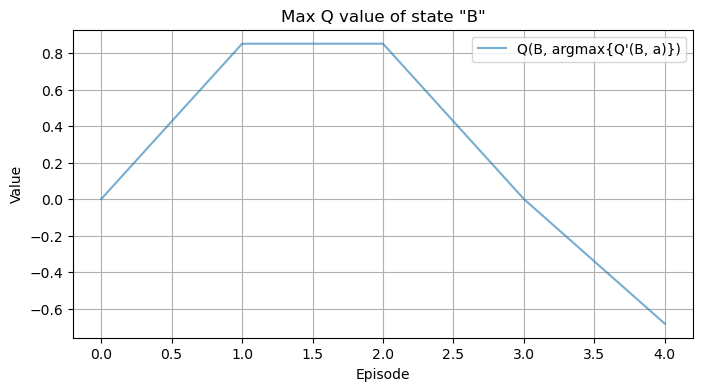

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(Qvalues, linestyle='-', alpha=0.6, label='Q(B, argmax{Q\'(B, a)})')

plt.xlabel('Episode')
plt.ylabel('Value')
plt.title('Max Q value of state \"B\"')
plt.grid(True)
plt.legend()
plt.show()